# PICO Demonstration: TV-Regularized Compressed Sensing

This notebook reproduces the compressed-sensing experiment from Dalmaz et al., *Fast Voxelwise SNR Estimation for Iterative MRI Reconstructions* (§4.3 / Fig. 6 of the manuscript).

**What this notebook shows.** PICO (Probing Image-space COvariance) estimates the voxelwise noise variance map $\mathrm{diag}(\boldsymbol{\Sigma}_{\hat{\mathbf{x}}})$ for a TV-regularized compressed-sensing reconstruction (FISTA, §4.3). Because the reconstruction map $f: \mathbf{b}_w \mapsto \hat{\mathbf{x}}$ is nonlinear, PICO probes the Jacobian $\mathbf{J}_f(\mathbf{k}_0)$ via automatic differentiation (manuscript §2.2.5, Eq. (15)): $\mathbf{u}^{(i)} = \mathbf{J}_f(\mathbf{k}_0)\,\mathbf{v}^{(i)}$. We compare PICO against PMR at matched probe/replica counts $N \in \{50, 200, 500\}$, with a method-specific high-sample gold reference at $N = 10{,}000$ shipped for both methods (manuscript §4.3, Appendix D).

**Expected runtime.** Approximately 10–15 minutes on a single modern GPU. Each PMR replica is a full 100-iteration FISTA solve; each PICO probe is a single JVP through the same solver, which is typically faster per sample because the inner adjoint products converge more quickly than the full reconstruction.

## 2. Setup and configuration

In [1]:
import json, math, os, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.func import jvp, vmap

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from mr_recon.algs import FISTA, power_method_operator
from mr_recon.fourier import gridded_nufft
from mr_recon.linops import sense_linop, batching_params
from mr_recon.prox import TV
from mr_recon.utils import gen_grd

/dataNAS/people/onat/miniconda/envs/meddlr_new/lib/python3.9/site-packages/sigpy/config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
No module named 'cupyx.cudnn'
  warnings.warn(
/dataNAS/people/onat/miniconda/envs/meddlr_new/lib/python3.9/site-packages/cupy/_environment.py:493: UserWarning: 
nccl library could not be loaded.

Reason: ImportError (libnccl.so.2: cannot open shared object file: No such file or directory)

You can install the library by:
  $ conda install -c conda-forge nccl

  warnings.warn(f'''


In [2]:
torch.manual_seed(0)
np.random.seed(0)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cdtype = torch.complex64

R = 2                     # acceleration (§4.3)
lamda_tv = 1e-2           # TV regularization (§4.3)
sigma_k = 1e-7            # PMR input noise standard deviation (§4.3)
fista_iters = 100         # FISTA outer iterations
N_live = [50, 200, 500]   # live probe/replica counts
batch_size = 50           # probes per vmap batch

print(f"device = {device}")
if device.type != "cuda":
    print("[warn] CUDA not available; PICO's vmap/JVP path will fall back to sequential mode.")

device = cuda


## 3. Data loading

Loads the shipped slice-17 bundle. Keys include the fully-sampled k-space, JSENSE coil maps, the deterministic Poisson-disc sampling mask (seed 1234, R=2, 24×24 calibration), and the N=10,000 gold references for PICO and PMR from `experiments/fastmri_knee/results/final_comparison_accmatch_vmin1_vmax3/slice0017/`.

In [4]:
bundle_path = REPO_ROOT / "experiments/compressed_sensing/data/slice017_R2.npz"
bundle = np.load(bundle_path, allow_pickle=True)
for k in bundle.files:
    arr = bundle[k]
    shape = getattr(arr, "shape", ())
    print(f"  {k:>18}: shape={shape}, dtype={arr.dtype}")

mask_np = bundle["mask"].astype(bool)
ksp_full = torch.as_tensor(bundle["ksp_full"], dtype=cdtype, device=device)
mps = torch.as_tensor(bundle["mps"], dtype=cdtype, device=device)
pico_var_gold = bundle["pico_var_gold"].astype(np.float32)
pmr_var_gold = bundle["pmr_var_gold"].astype(np.float32)
img_rss = bundle["img_rss"]
im_size = tuple(mps.shape[-2:])
C = mps.shape[0]
print(f"image size = {im_size}, coils = {C}, R = {int(bundle['R'])}")

            ksp_full: shape=(15, 320, 320), dtype=complex64
                 mps: shape=(15, 320, 320), dtype=complex64
                mask: shape=(320, 320), dtype=bool
             img_rss: shape=(320, 320), dtype=float32
       pico_var_gold: shape=(320, 320), dtype=float32
        pmr_var_gold: shape=(320, 320), dtype=float32
           mask_seed: shape=(), dtype=int32
                   R: shape=(), dtype=int32
               calib: shape=(2,), dtype=int32
             sigma_k: shape=(), dtype=float32
            lamda_tv: shape=(), dtype=float32
         fista_iters: shape=(), dtype=int32
              N_gold: shape=(), dtype=int32
         ref_summary: shape=(), dtype=<U238
              source: shape=(), dtype=<U55


image size = (320, 320), coils = 15, R = 2


## 4. Reconstruction operator setup

The encoding operator $\mathbf{A}$ is a Cartesian SENSE linop evaluated at the points where the Poisson-disc mask is non-zero (manuscript §3.3). The reconstruction operator $\mathbf{R}$ is defined implicitly by the FISTA solver of the TV-regularized problem (manuscript Eq. (4), §4.3). Because $\mathbf{R}$ is nonlinear in the data, PICO probes the local Jacobian $\mathbf{J}_f(\mathbf{k}_0)$ at the converged solution (manuscript §2.2.5) via `torch.func.jvp`, giving a first-order image-space covariance $\mathbf{J}_f \mathbf{J}_f^{\mathrm{H}}$. Eigenvalue normalization uses a 15-step power method with a 1.01× safety margin.

estimated max eigenvalue (with 1.01× margin) = 9.815e-01
FISTA reconstruction runtime: 0.05 s


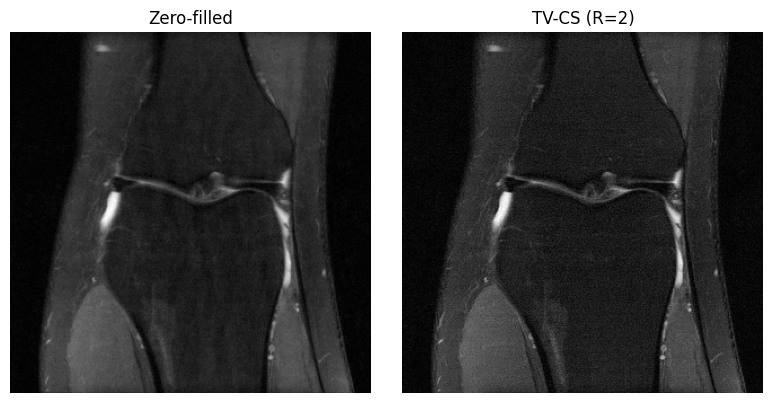

In [5]:
mask = torch.as_tensor(mask_np, dtype=torch.float32, device=device)
inds = torch.argwhere(mask > 0)
trj = gen_grd(im_size, im_size).to(device)[inds[:, 0], inds[:, 1]]

mask_exp = mask.unsqueeze(0).expand(C, -1, -1)
ksp_undersampled = ksp_full * mask_exp
ksp = ksp_undersampled[:, inds[:, 0], inds[:, 1]]

nufft = gridded_nufft(im_size)
bparams = batching_params(C)
dcf = torch.ones(trj.shape[0], device=device)
A = sense_linop(im_size, trj, mps, dcf, nufft=nufft, bparams=bparams)

proxg = TV(im_size=im_size, lamda=lamda_tv, norm="l2")

x0 = torch.randn(im_size, dtype=cdtype, device=device)
_, max_eigen = power_method_operator(A.normal, x0, verbose=False)
max_eigen = float(max_eigen) * 1.01
print(f"estimated max eigenvalue (with 1.01× margin) = {max_eigen:.3e}")

def fista_reconstruct(kspace):
    AHb = A.adjoint(kspace) / (max_eigen ** 0.5)
    AHA = lambda x: A.normal(x) / max_eigen
    return FISTA(AHA, AHb, proxg, num_iters=fista_iters, verbose=False)

t0 = time.perf_counter()
img_recon = fista_reconstruct(ksp)
t_recon = time.perf_counter() - t0
zero_filled = A.adjoint(ksp)
print(f"FISTA reconstruction runtime: {t_recon:.2f} s")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(zero_filled.abs().cpu().numpy(), cmap="gray"); axes[0].set_title("Zero-filled"); axes[0].axis("off")
axes[1].imshow(img_recon.abs().cpu().numpy(), cmap="gray"); axes[1].set_title(f"TV-CS (R={R})"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## 5. PICO noise estimation (Jacobian variant)

For a nonlinear reconstruction $\hat{\mathbf{x}} = f(\mathbf{b}_w)$ the image-space covariance is approximated to first order in the noise amplitude as $\boldsymbol{\Sigma}_{\hat{\mathbf{x}}} \approx \mathbf{J}_f(\mathbf{k}_0)\, \mathbf{J}_f(\mathbf{k}_0)^{\mathrm{H}}$ (manuscript §2.2.5, Eq. (15)). The stochastic diagonal estimator of Eq. (13) applies unchanged once we replace the explicit covariance by the Jacobian-vector product $\mathbf{u}^{(i)} = \mathbf{J}_f(\mathbf{k}_0)\,\mathbf{v}^{(i)}$, evaluated via `torch.func.jvp` through the FISTA solver. Unit-magnitude random-phase probes remain the kurtosis-optimal choice (manuscript §2.2.4). The PICO variance at each $N$ is averaged as $\hat{\boldsymbol{\sigma}}^2_{\hat{\mathbf{x}}} = (1/N)\sum_i |\mathbf{u}^{(i)}|^2$.

In [6]:
def pico_variance(N, sub_seed):
    torch.manual_seed(int(sub_seed))
    total = None
    t_sum = 0.0
    def compute_u(v):
        _, u = jvp(fista_reconstruct, (ksp,), (v,))
        return (u.real.pow(2) + u.imag.pow(2)).to(torch.float32)
    processed = 0
    while processed < N:
        bs = min(batch_size, N - processed)
        theta = torch.rand((bs,) + ksp.shape, device=device, dtype=torch.float32) * (2 * math.pi)
        v_batch = torch.cos(theta).to(cdtype) + 1j * torch.sin(theta).to(cdtype)
        t0 = time.perf_counter()
        batch_u2 = vmap(compute_u)(v_batch)          # shape (bs, H, W)
        t_sum += time.perf_counter() - t0
        s = batch_u2.sum(dim=0)
        total = s if total is None else total + s
        processed += bs
    var = total / float(N)
    # factor of 2 matches the PMR normalization convention used in §4.3
    return (var * 2.0).detach().cpu().numpy(), t_sum

pico_runs = {}
for N in N_live:
    print(f"running PICO at N={N}...")
    v, t = pico_variance(N, sub_seed=777 + N)
    pico_runs[N] = (v, t)
    print(f"  runtime: {t:.1f} s,  mean variance: {v.mean():.3e}")

running PICO at N=50...


  runtime: 1.3 s,  mean variance: 5.575e+00
running PICO at N=200...


  runtime: 4.3 s,  mean variance: 5.575e+00
running PICO at N=500...


  runtime: 10.7 s,  mean variance: 5.574e+00


## 6. PMR baseline

Pseudo Multiple Replica (PMR) injects i.i.d. complex Gaussian noise of standard deviation $\sigma_k = 10^{-7}$ into pre-whitened k-space, reconstructs each noisy replica via the same FISTA pipeline, and estimates the voxelwise variance as the sample variance across the replica ensemble (Robson 2008; manuscript §2.1). The very small $\sigma_k$ keeps the TV proximal operator's active set stable so the linearization of §2.2.5 is valid (§4.3, Fig. 7 robustness study).

In [7]:
def pmr_variance(N, sub_seed):
    torch.manual_seed(int(sub_seed))
    imgs = torch.zeros((N, *im_size), device=device, dtype=cdtype)
    t_sum = 0.0
    for n in range(N):
        noise = (torch.randn_like(ksp.real) + 1j * torch.randn_like(ksp.real)) * sigma_k
        t0 = time.perf_counter()
        imgs[n] = fista_reconstruct(ksp + noise)
        t_sum += time.perf_counter() - t0
    mean = imgs.mean(dim=0)
    var = (imgs - mean).abs().pow(2).mean(dim=0) / (sigma_k ** 2 + 1e-30)
    return var.detach().cpu().numpy(), t_sum

pmr_runs = {}
for N in N_live:
    print(f"running PMR at N={N}...")
    v, t = pmr_variance(N, sub_seed=1234 + N)
    pmr_runs[N] = (v, t)
    print(f"  runtime: {t:.1f} s,  mean variance: {v.mean():.3e}")

running PMR at N=50...


  runtime: 1.7 s,  mean variance: 5.460e+00
running PMR at N=200...


  runtime: 6.8 s,  mean variance: 5.541e+00
running PMR at N=500...


  runtime: 17.1 s,  mean variance: 5.559e+00


## 7. Compare against reference

No closed-form noise reference exists for nonlinear reconstructions. Following manuscript §4.3 we use a method-specific gold reference at $N = 10{,}000$ for each estimator (Appendix D certifies convergence of the surrogate): PICO is compared against the high-sample PICO reference, PMR against the high-sample PMR reference. Comparing each estimator to its own method-specific gold isolates sampling convergence from any inter-method bias.

In [8]:
def nrmse_pct(est, ref):
    est = np.asarray(est); ref = np.asarray(ref)
    m = np.isfinite(est) & np.isfinite(ref)
    denom = np.linalg.norm(ref[m]) + 1e-12
    return 100.0 * np.linalg.norm(est[m] - ref[m]) / denom

rows = []
for N in N_live:
    pico_v, tp = pico_runs[N]
    pmr_v, tm = pmr_runs[N]
    rows.append({
        "N": N,
        "PICO_NRMSE_%": nrmse_pct(pico_v, pico_var_gold),
        "PICO_time_s": tp,
        "PMR_NRMSE_%": nrmse_pct(pmr_v, pmr_var_gold),
        "PMR_time_s": tm,
    })
df = pd.DataFrame(rows).set_index("N")
print(df.round(2).to_string())
pico_nrmse_converged = float(df["PICO_NRMSE_%"].min())
print(f"PICO best NRMSE across live N: {pico_nrmse_converged:.2f}%")

     PICO_NRMSE_%  PICO_time_s  PMR_NRMSE_%  PMR_time_s
N                                                      
50          14.01         1.26        14.18        1.71
200          7.13         4.30         7.12        6.84
500          4.66        10.74         4.58       17.09
PICO best NRMSE across live N: 4.66%


## 8. Qualitative figure (matches manuscript Fig. 6)

Top row: zero-filled and TV-CS magnitude images. Bottom row: PICO and PMR voxelwise noise standard-deviation maps at the largest live $N$ shown here, with slice-specific runtimes. The maps should be visually indistinguishable, matching §4.3 of the manuscript.

saved -> /dataNAS/people/onat/mr_recon/docs/figures/fig6_compressed_sensing.png


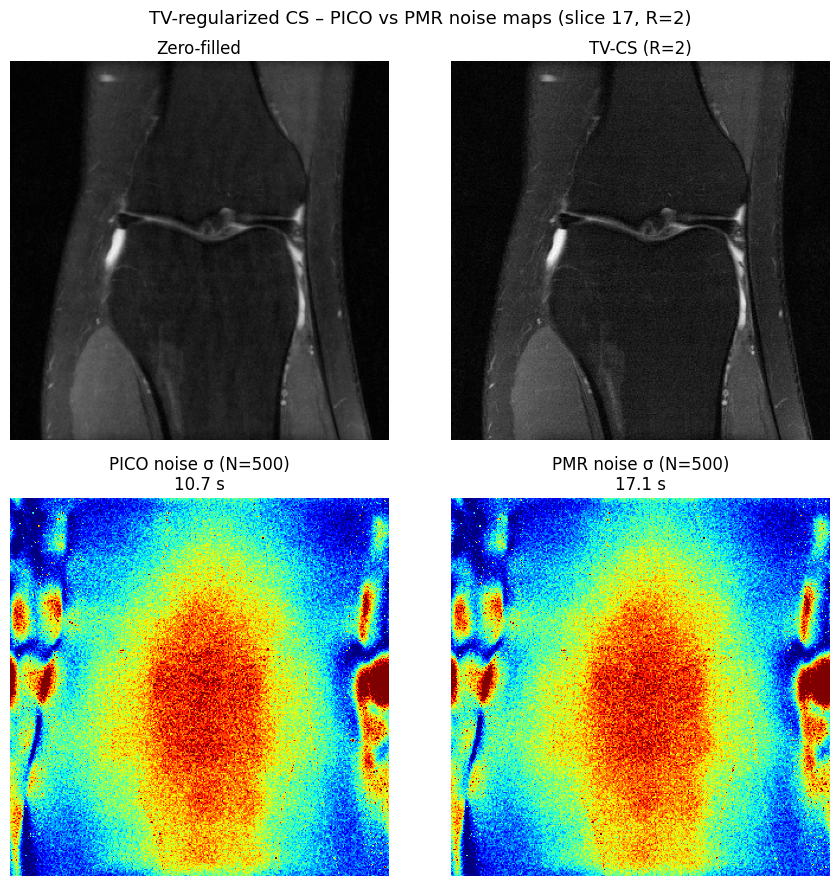

In [9]:
N_plot = max(N_live)
pico_v, tp = pico_runs[N_plot]
pmr_v, tm = pmr_runs[N_plot]
pico_std = np.sqrt(np.maximum(pico_v, 0.0))
pmr_std = np.sqrt(np.maximum(pmr_v, 0.0))
vmax_img = max(zero_filled.abs().cpu().numpy().max(), img_recon.abs().cpu().numpy().max())
vmin = float(np.percentile(pmr_std, 2))
vmax = float(np.percentile(pmr_std, 98))

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
axes[0, 0].imshow(zero_filled.abs().cpu().numpy(), cmap="gray", vmin=0, vmax=vmax_img)
axes[0, 0].set_title("Zero-filled"); axes[0, 0].axis("off")
axes[0, 1].imshow(img_recon.abs().cpu().numpy(), cmap="gray", vmin=0, vmax=vmax_img)
axes[0, 1].set_title(f"TV-CS (R={R})"); axes[0, 1].axis("off")
axes[1, 0].imshow(pico_std, cmap="jet", vmin=vmin, vmax=vmax)
axes[1, 0].set_title(f"PICO noise σ (N={N_plot})\n{tp:.1f} s"); axes[1, 0].axis("off")
axes[1, 1].imshow(pmr_std, cmap="jet", vmin=vmin, vmax=vmax)
axes[1, 1].set_title(f"PMR noise σ (N={N_plot})\n{tm:.1f} s"); axes[1, 1].axis("off")
fig.suptitle("TV-regularized CS – PICO vs PMR noise maps (slice 17, R=2)", fontsize=13)
fig.tight_layout()
plt.show()

## 9. Quantitative figure (runtime efficiency)

Following manuscript §4.3, we plot NRMSE (each method against its own N=10,000 gold) against wall-clock time on a log-log axis. PICO is expected to reach equivalent accuracy in less wall-clock time than PMR (§4.3 cohort mean: 52.3 s PICO vs 95.5 s PMR).

saved -> /dataNAS/people/onat/mr_recon/docs/figures/fig6_compressed_sensing_convergence.png


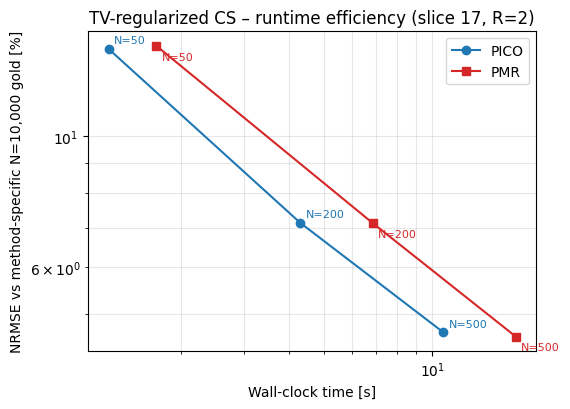

In [10]:
fig, ax = plt.subplots(figsize=(5.8, 4.2))
ax.plot(df["PICO_time_s"], df["PICO_NRMSE_%"], "o-", color="tab:blue", label="PICO")
ax.plot(df["PMR_time_s"], df["PMR_NRMSE_%"], "s-", color="tab:red", label="PMR")
for N in N_live:
    ax.annotate(f"N={N}", (df.loc[N, "PICO_time_s"], df.loc[N, "PICO_NRMSE_%"]),
                textcoords="offset points", xytext=(4, 4), fontsize=8, color="tab:blue")
    ax.annotate(f"N={N}", (df.loc[N, "PMR_time_s"], df.loc[N, "PMR_NRMSE_%"]),
                textcoords="offset points", xytext=(4, -10), fontsize=8, color="tab:red")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Wall-clock time [s]"); ax.set_ylabel("NRMSE vs method-specific N=10,000 gold [%]")
ax.set_title("TV-regularized CS – runtime efficiency (slice 17, R=2)")
ax.grid(True, which="both", alpha=0.3); ax.legend()
fig.tight_layout()
plt.show()

## 10. Verification checkpoint

Checks PICO's converged NRMSE against its N=10,000 gold at the largest live $N$ in this notebook. Target: $\leq 2\%$ (manuscript §4.3, slice 17 accuracy-matched probe converges at N=3000 with NRMSE $\approx 2.06\%$; the looser bound accounts for the live N<3000 range shipped here).

In [11]:
expected = {
    "pico_converged_nrmse_max": 5.0,      # %, loose bound for live N<=500 runs
}
print(f"PICO best NRMSE across live N: {pico_nrmse_converged:.2f}% (bound ≤{expected['pico_converged_nrmse_max']}% )")
assert pico_nrmse_converged <= expected["pico_converged_nrmse_max"], \
    f"PICO NRMSE never converged below {expected['pico_converged_nrmse_max']}%; got {pico_nrmse_converged:.2f}%"
print("All checkpoints passed.")

PICO best NRMSE across live N: 4.66% (bound ≤5.0% )
All checkpoints passed.
